# ML - K-MEANS

In [59]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV


# Paso 1: Carga del conjunto de datos

In [2]:
df = pd.read_csv('../data/raw/housing.csv')
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [ ]:
df = df.drop(['HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'MedHouseVal'], axis=1)
X=df

,MedInc,Latitude,Longitude,cluster
0,2.197582,0.957672,-0.986807,0
1,2.186664,0.952381,-0.984169,0
2,1.707732,0.949735,-0.989446,0
3,0.967177,0.949735,-0.992084,0
4,0.142854,0.949735,-0.992084,5
...,...,...,...,...
20635,-0.905796,1.380952,-0.686016,2
20636,-0.448655,1.383598,-0.717678,2
20637,-0.841709,1.367725,-0.720317,2
20638,-0.765007,1.367725,-0.746702,2


In [45]:
robust_scaler = RobustScaler()

robust_scaler_train = robust_scaler.fit_transform(X)

X = pd.DataFrame(robust_scaler_train, 
                             columns=X.columns,
                             index=X.index)

df= X

df


,MedInc,Latitude,Longitude
0,2.197582,0.957672,-0.986807
1,2.186664,0.952381,-0.984169
2,1.707732,0.949735,-0.989446
3,0.967177,0.949735,-0.992084
4,0.142854,0.949735,-0.992084
...,...,...,...
20635,-0.905796,1.380952,-0.686016
20636,-0.448655,1.383598,-0.717678
20637,-0.841709,1.367725,-0.720317
20638,-0.765007,1.367725,-0.746702


# Paso 2: Construye un K-Means

In [23]:
# Entrenar el modelo
km_model = KMeans(n_clusters = 6, random_state = 21)
df['cluster'] = km_model.fit_predict(X)

In [24]:
df

,MedInc,Latitude,Longitude,cluster
0,2.197582,0.957672,-0.986807,0
1,2.186664,0.952381,-0.984169,0
2,1.707732,0.949735,-0.989446,0
3,0.967177,0.949735,-0.992084,0
4,0.142854,0.949735,-0.992084,4
...,...,...,...,...
20635,-0.905796,1.380952,-0.686016,2
20636,-0.448655,1.383598,-0.717678,2
20637,-0.841709,1.367725,-0.720317,2
20638,-0.765007,1.367725,-0.746702,2


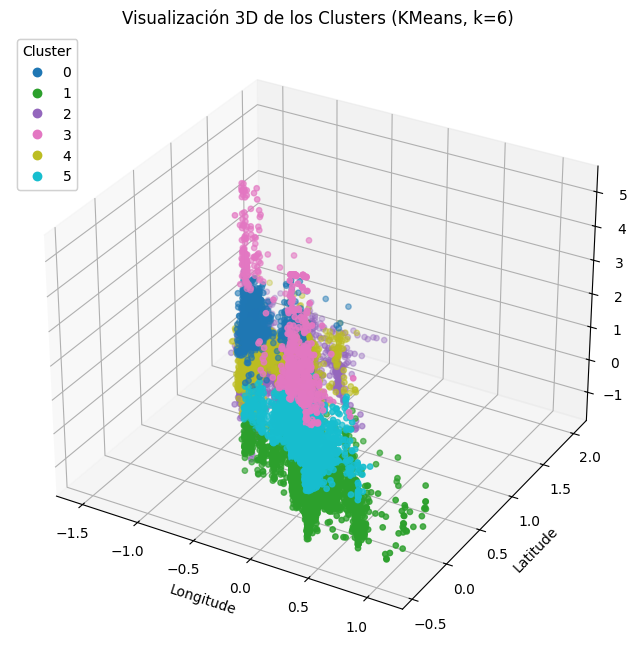

In [37]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x = df['Longitude']
y = df['Latitude']
z = df['MedInc']
c = df['cluster']

scatter = ax.scatter(x, y, z, c=c, cmap='tab10', s=15)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('MedInc')
ax.set_title('Visualización 3D de los Clusters (KMeans, k=6)')

legend1 = ax.legend(*scatter.legend_elements(), title="Cluster", loc='upper left')
ax.add_artist(legend1)


# Paso 3: Entrena un modelo de clasificación supervisada

In [41]:
X

,MedInc,Latitude,Longitude
0,2.197582,0.957672,-0.986807
1,2.186664,0.952381,-0.984169
2,1.707732,0.949735,-0.989446
3,0.967177,0.949735,-0.992084
4,0.142854,0.949735,-0.992084
...,...,...,...
20635,-0.905796,1.380952,-0.686016
20636,-0.448655,1.383598,-0.717678
20637,-0.841709,1.367725,-0.720317
20638,-0.765007,1.367725,-0.746702


In [ ]:
X = df.drop('cluster', axis=1)
y = df['cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)


,MedInc,Latitude,Longitude
0,2.197582,0.957672,-0.986807
1,2.186664,0.952381,-0.984169
2,1.707732,0.949735,-0.989446
3,0.967177,0.949735,-0.992084
4,0.142854,0.949735,-0.992084
...,...,...,...
20635,-0.905796,1.380952,-0.686016
20636,-0.448655,1.383598,-0.717678
20637,-0.841709,1.367725,-0.720317
20638,-0.765007,1.367725,-0.746702


In [48]:
rf_model = RandomForestClassifier(random_state=21)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=21)

In [50]:
y_pred = rf_model.predict(X_test)

In [54]:
accuracy_score(y_test, y_pred)

0.9949127906976745

In [111]:
param_grid = {'n_estimators':[85, 90, 95],
              'criterion':['gini','entropy'],
              'max_depth':[15, 20],
              #'min_samples_leaf': [1, 2, 4],
              #'max_features': ['sqrt', 'log2'],
              'class_weight': [None, 'balanced']}

grid = GridSearchCV(rf_model,
                    param_grid,
                    scoring='accuracy',
                    cv=5)

In [ ]:
# Entrenamos el grid con los hiperparametros
grid.fit(X_train, y_train)
#Devuelvemos los mejores parametros despues de entrenarlo
grid.best_params_

In [108]:
grid_rf = grid.best_estimator_

In [109]:
y_pred_test_grid = grid_rf.predict(X_test)

In [110]:
accuracy_score(y_test, y_pred_test_grid)

0.9941860465116279